# 02 — RAG Router Agent (Chatbot)
### An agent that decides *which* knowledge source(s) to consult, then answers

This notebook assumes you've already run **`01_ingestion.ipynb`** so that:
- Pinecone index `company-policies` has policy chunks
- Pinecone index `product-manuals` has manual chunks
- `company_data.db` (SQLite) has `inventory` / `orders` tables

## The architecture

```
                    Question
                       |
                       v
                  [ route_node ]        <- LLM decides which source(s) are relevant
                    /   |   \
                   /    |    \
          [policy]  [product]  [sql]    <- run in PARALLEL, only the chosen branches
             \          |         /
              \         |        /
                 [ generate_node ]      <- fan-in: combine + synthesize final answer
                       |
                       v
                    Answer
```

We build this as a **LangGraph `StateGraph`** rather than a linear chain because the
number and identity of branches that run is decided *at runtime* by the router — that's
a graph problem (conditional fan-out / fan-in), not a straight-line pipeline.


## 1. Install packages

In [ ]:
# %pip install -q -U langchain langchain-community langchain-openai \
#     langgraph langchain-pinecone


In [1]:
import importlib.metadata

# List the distribution package names
packages = ["langchain", "langchain-community", "langchain-openai", 
            "langchain-text-splitters", "langchain-pinecone",
            "pypdf"]

for package in packages:
    try:
        version = importlib.metadata.version(package)
        print(f"{package} version: {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{package} is not installed in this environment.")


# langchain version: 1.3.6
# langchain-community version: 0.4.2
# langchain-openai version: 1.2.2
# langchain-text-splitters version: 1.1.2
# langchain-pinecone version: 0.2.13
# pypdf version: 6.10.2

langchain version: 1.3.6
langchain-community version: 0.4.2
langchain-openai version: 1.2.2
langchain-text-splitters version: 1.1.2
langchain-pinecone version: 0.2.13
pypdf version: 6.10.2


## 2. Configuration & clients

Same environment variables as the ingestion notebook — this is a *read* path, so no
new credentials are needed beyond OpenAI + Pinecone.

In [2]:
from dotenv import load_dotenv
import os

# Load the .env file
load_dotenv()


True

In [7]:
import os
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import create_sql_agent
from pinecone import Pinecone

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
PINECONE_API_KEY = os.environ["PINECONE_API_KEY"]

POLICY_INDEX_NAME = "company-policies-index"
PRODUCT_INDEX_NAME = "product-manuals-index"
SQLITE_URI = "sqlite:///company_data.db"     # same file created in notebook 1

CHAT_MODEL = "gpt-4o"
EMBEDDING_MODEL = "text-embedding-3-small"

In [4]:
# Test keys

import os
from openai import OpenAI
from pinecone import Pinecone

# 1. Ensure keys are pulled from environment variables
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
PINECONE_API_KEY = os.environ.get("PINECONE_API_KEY")

print("--- Testing API Keys ---")

# 2. Test OpenAI Key
try:
    # Initialize the client (automatically uses os.environ["OPENAI_API_KEY"])
    client = OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o-mini",  # Fast and cost-efficient model
        messages=[
            {"role": "user", "content": "Hi"}
        ]
    )
    print("Response from OpenAI:", response.choices[0].message.content)
    print("✅ OpenAI API Key: SUCCESS (Valid connection)")
    
except Exception as e:
    print(f"❌ OpenAI API Key: FAILED. Error: {e}")

# 3. Test Pinecone Key
try:
    # Initialize the client (automatically uses os.environ["PINECONE_API_KEY"])
    pc = Pinecone()
    pc.list_indexes() # Make a minimal API call to list existing vector indexes
    print("✅ Pinecone API Key: SUCCESS (Valid connection)")
    
except Exception as e:
    print(f"❌ Pinecone API Key: FAILED. Error: {e}")


--- Testing API Keys ---
Response from OpenAI: Hello! How can I assist you today?
✅ OpenAI API Key: SUCCESS (Valid connection)
✅ Pinecone API Key: SUCCESS (Valid connection)


In [5]:

llm = ChatOpenAI(model=CHAT_MODEL, temperature=0, api_key=OPENAI_API_KEY)

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL, api_key=OPENAI_API_KEY)

pc = Pinecone(api_key=PINECONE_API_KEY)


## 3. Connect the three knowledge sources

Nothing is created here — we're just opening connections to what notebook 1 built.

In [8]:
# --- Vector retrievers (Pinecone) ---
policy_store = PineconeVectorStore(index=pc.Index(POLICY_INDEX_NAME), embedding=embeddings)
product_store = PineconeVectorStore(index=pc.Index(PRODUCT_INDEX_NAME), embedding=embeddings)

policy_retriever = policy_store.as_retriever(search_kwargs={"k": 4})
product_retriever = product_store.as_retriever(search_kwargs={"k": 4})

# --- SQL agent (SQLite) ---
sql_db = SQLDatabase.from_uri(SQLITE_URI)
sql_agent = create_sql_agent(
    llm=llm,
    db=sql_db,
    agent_type="tool-calling",   # current recommended agent type
    verbose=False,
    max_iterations=8,
)

print("Connected to:", POLICY_INDEX_NAME, "|", PRODUCT_INDEX_NAME, "|", SQLITE_URI)


Connected to: company-policies-index | product-manuals-index | sqlite:///company_data.db


## 4. Define the shared graph state

Every node reads/writes this single `TypedDict`. Each retrieval node only ever writes
its *own* key (`policy_docs`, `product_docs`, `sql_result`), which is what makes it safe
for LangGraph to run several of them in parallel without conflicts.

In [9]:
from typing import List, Literal, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict, total=False):
    question: str
    sources: List[str]
    policy_docs: List[Document]
    product_docs: List[Document]
    sql_result: str
    answer: str


## 5. The router node

This is the "brain" of source selection. We use **structured output** — the LLM must
return a `RouteDecision` object, not free text — so the routing decision is a reliable
Python list we can act on, not something we have to parse out of prose.

In [10]:
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage

class RouteDecision(BaseModel):
    sources: List[Literal["policy", "product", "sql"]] = Field(
        description="Knowledge source(s) needed to answer the question. "
        "Include more than one if the question spans domains."
    )
    reasoning: str = Field(description="One sentence justification.")

router_llm = llm.with_structured_output(RouteDecision)

ROUTER_SYSTEM_PROMPT = """
You route user questions to one or more knowledge sources.

Sources:
- policy: Company Policies (HR, leave, code of conduct, expenses, compliance, procedures)
- product: Product Manuals (specs, how-to, installation, troubleshooting, features)
- sql: SQL Database (structured records -- orders, inventory/stock counts, customers,
  transactions, prices; anything requiring counting, filtering, or looking up specific rows)

Rules:
- Pick every source that is actually needed -- do not default to one.
- A question can legitimately need 2 or all 3 sources
  (e.g. "What's our return policy, and how many units of the X200 do we have in stock?"
  needs policy + sql).
- If unsure between two, include both rather than guessing wrong.
"""

def route_node(state: AgentState) -> AgentState:
    decision = router_llm.invoke([
        SystemMessage(content=ROUTER_SYSTEM_PROMPT),
        HumanMessage(content=state["question"]),
    ])
    print(f"  [router] -> {decision.sources}   ({decision.reasoning})")
    return {"sources": decision.sources}

def route_condition(state: AgentState) -> List[str]:
    """Tell LangGraph which node(s) to run next -- this is the fan-out step."""
    return state["sources"] or ["product"]   # never fan out to zero branches


## 6. Retrieval nodes

One small function per source. Each takes the shared state in and returns *only* the
key it's responsible for.

In [11]:
def policy_node(state: AgentState) -> AgentState:
    docs = policy_retriever.invoke(state["question"])
    return {"policy_docs": docs}

def product_node(state: AgentState) -> AgentState:
    docs = product_retriever.invoke(state["question"])
    return {"product_docs": docs}

def sql_node(state: AgentState) -> AgentState:
    result = sql_agent.invoke({"input": state["question"]})
    return {"sql_result": result.get("output", "")}


## 7. Generate node (fan-in)

This node runs exactly once per question, *after* every branch the router picked has
finished. It only assembles context from the keys that are actually present, so it
naturally handles the 1-source, 2-source, and 3-source cases with the same code.

In [12]:
SYNTHESIS_SYSTEM_PROMPT = """
Answer the user's question using ONLY the context provided.
Attribute each fact to its source in brackets: [Policy], [Product Manual], or [Database].
If the context doesn't fully answer the question, say what's missing rather than guessing.
Be concise.
"""

def generate_node(state: AgentState) -> AgentState:
    parts = []
    if state.get("policy_docs"):
        joined = "\n\n".join(d.page_content for d in state["policy_docs"])
        parts.append(f"=== COMPANY POLICY ===\n{joined}")
    if state.get("product_docs"):
        joined = "\n\n".join(d.page_content for d in state["product_docs"])
        parts.append(f"=== PRODUCT MANUAL ===\n{joined}")
    if state.get("sql_result"):
        parts.append(f"=== DATABASE RESULT ===\n{state['sql_result']}")

    context = "\n\n".join(parts) if parts else "No relevant context was retrieved."

    response = llm.invoke([
        SystemMessage(content=SYNTHESIS_SYSTEM_PROMPT),
        HumanMessage(content=f"Question: {state['question']}\n\nContext:\n{context}"),
    ])
    return {"answer": response.content}


## 8. Assemble the graph

This is the only place the *shape* of the workflow is defined — nodes, then edges.
`add_conditional_edges(..., ["policy", "product", "sql"])` is what enables the fan-out:
LangGraph will run every node that `route_condition` returned, in parallel, in one step.

In [13]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)
graph.add_node("route", route_node)
graph.add_node("policy", policy_node)
graph.add_node("product", product_node)
graph.add_node("sql", sql_node)
graph.add_node("generate", generate_node)

graph.add_edge(START, "route")
graph.add_conditional_edges("route", route_condition, ["policy", "product", "sql"])
graph.add_edge("policy", "generate")
graph.add_edge("product", "generate")
graph.add_edge("sql", "generate")
graph.add_edge("generate", END)

app = graph.compile()
print("Graph compiled.")


Graph compiled.


### Visualize the graph

Renders the actual structure we just built.

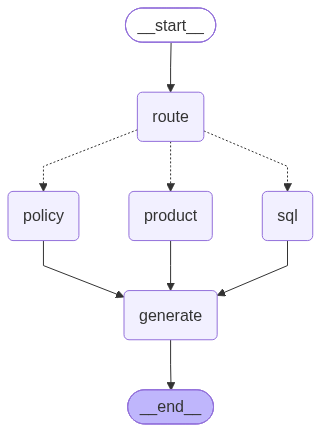

In [14]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # Falls back to ASCII if graphviz/mermaid rendering isn't available in this environment
    print(app.get_graph().draw_ascii())


## 9. Try it — single questions

Watch the `[router]` print line to see which source(s) get chosen for each question.

In [14]:
def ask(question: str) -> str:
    result = app.invoke({"question": question})
    return result["answer"]

question = "What is our remote work policy?"
answer = ask(question) 

print(answer)


  [router] -> ['policy']   (The question is about company policies regarding remote work, which falls under HR and company procedures.)
Our remote work policy allows employees to work remotely up to three days per week with their direct manager's approval. The remaining two days should be spent at a Loxford office to support in-person collaboration, unless the employee's role is designated as fully remote. Fully remote arrangements require approval from a Vice President and a documented home-office setup meeting Loxford's minimum standards. All employees are expected to be reachable between 10:00 AM and 3:00 PM in their local time zone, unless otherwise agreed with their manager [Policy].


In [17]:
# A question that needs to read manuals

question = "How do I factory reset the X200 router ?"
answer = ask(question) 

print(answer)

  [router] -> ['product']   (The question is about performing a factory reset on a specific product, which is covered in the product manuals.)
To factory reset the X200 router, follow these steps:

1. Locate the small Reset button on the back panel, next to the WAN port.
2. Using a paperclip or SIM tool, press and hold the button for 10 seconds.
3. Release the button once the Wi-Fi LED begins blinking amber.

This process will erase all settings and restore the router to its out-of-box state [Product Manual].


In [15]:
question = "How many units of the X200 router do we currently have in stock ?"
answer = ask(question) 

print(answer)


  [router] -> ['sql']   (The question requires looking up current inventory levels, which are stored in the SQL database.)
We currently have 42 units of the X200 router in stock [Database].


In [16]:
# A question that needs TWO sources at once -- watch the router pick both

question = "How do I factory reset the X200 router, and what's the warranty policy on it?"
answer = ask(question) 

print(answer)

  [router] -> ['product', 'policy']   (The question involves both the procedure to reset the router (product) and the warranty policy (policy).)
To factory reset the X200 router, locate the small Reset button on the back panel next to the WAN port. Use a paperclip or SIM tool to press and hold the button for 10 seconds, then release it once the Wi-Fi LED begins blinking amber [Product Manual].

The warranty policy for the X200 router provides a two-year limited warranty from the date of purchase, covering manufacturing defects under normal use. The warranty does not cover water damage, physical damage, or unauthorized modification of the hardware or firmware [Product Manual].


## 10. Interactive chat loop

Run this cell in class and type questions live. Type `exit` to stop.

In [ ]:
while True:
    q = input("You: ").strip()
    if q.lower() in {"exit", "quit"}:
        break
    result = app.invoke({"question": q})
    print(f"[routed to: {result['sources']}]")
    print("Bot:", result["answer"], "\n")


---
## Recap

- **Ingestion** (notebook 1) and **serving** (this notebook) are separate concerns —
  the agent never writes to Pinecone or SQLite, **it only reads**.
- The **router** is a structured-output LLM call, not a keyword rule — it generalizes to
  new phrasings without hand-written if/else logic.
- **Fan-out / fan-in** in LangGraph lets the agent consult exactly the sources a question
  needs — one, two, or all three — with a single graph and a single `generate` node.

## Add more knowledge data source
To add a 4th source (e.g. a CRM API): add one retrieval node, add it to
  `route_condition`'s allowed list, add one edge into `generate`. Nothing else changes.
